---



---

# **JOBSHEET 4 - SEGMENTASI GAMBAR**

---



---

NAMA : Muhammad Eka Sobirin

NIM : 3.34.23.2.14

Mata Kuliah : Pengolahan Citra

Dosen Pengampu : Ir. Prayitno, S.ST., M.T., Ph.D.



---



---


##**PRAKTIKUM 1**
###Segmentasi Menggunakan Thresholding Global dan Otsu

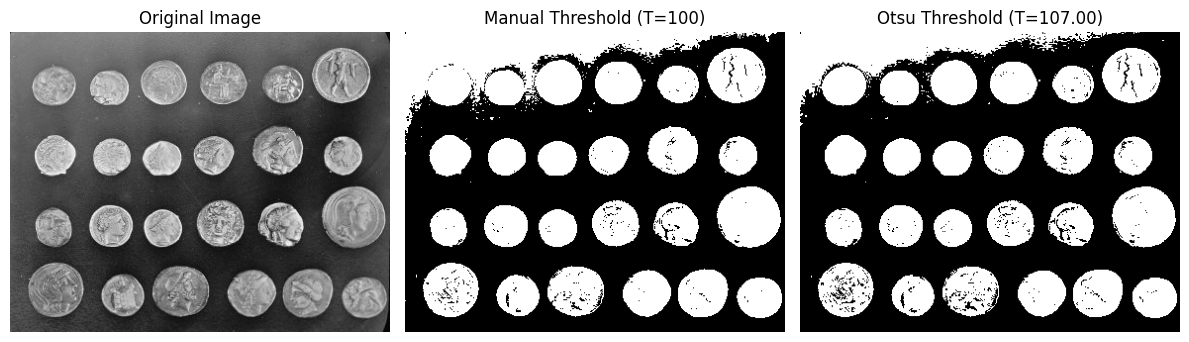

Nilai threshold Otsu: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra grayscale
image_coins = data.coins()   # gambar coins sudah grayscale

# 2. Thresholding Global (Manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otomatis (Metode Otsu)
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

# Threshold manual
ax[1].imshow(binary_manual, cmap='gray')
ax[1].set_title(f"Manual Threshold (T={thresh_manual})")
ax[1].axis("off")

# Threshold Otsu
ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title(f"Otsu Threshold (T={thresh_otsu:.2f})")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print("Nilai threshold Otsu:", thresh_otsu)

##**PRAKTIKUM 2**
### Segmentasi Menggunakan Region Growing (Contoh Sederhana)

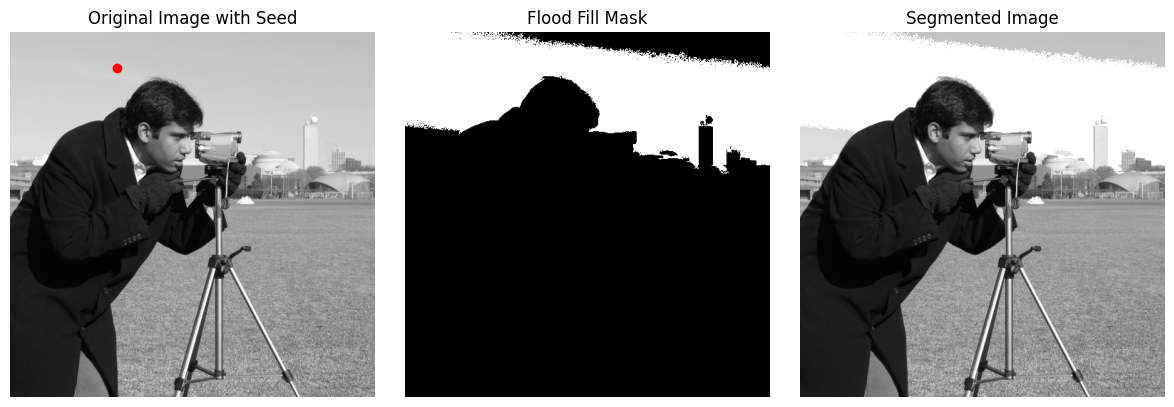

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Memuat citra grayscale
image_camera = data.camera()

# 2. Menentukan titik seed (benih)
# format: (baris/y, kolom/x)
seed_point = (50, 150)

# 3. Flood Fill / Region Growing
# tolerance = batas perbedaan intensitas piksel
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Membuat citra hasil segmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255   # region diberi warna putih

# 5. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title("Original Image with Seed")
ax[0].axis("off")

# Mask hasil flood fill
ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title("Flood Fill Mask")
ax[1].axis("off")

# Hasil segmentasi
ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title("Segmented Image")
ax[2].axis("off")

plt.tight_layout()
plt.show()

##**PRAKTIKUM 3**
### Segmentasi Citra Berwarna Menggunakan K-Means Clustering

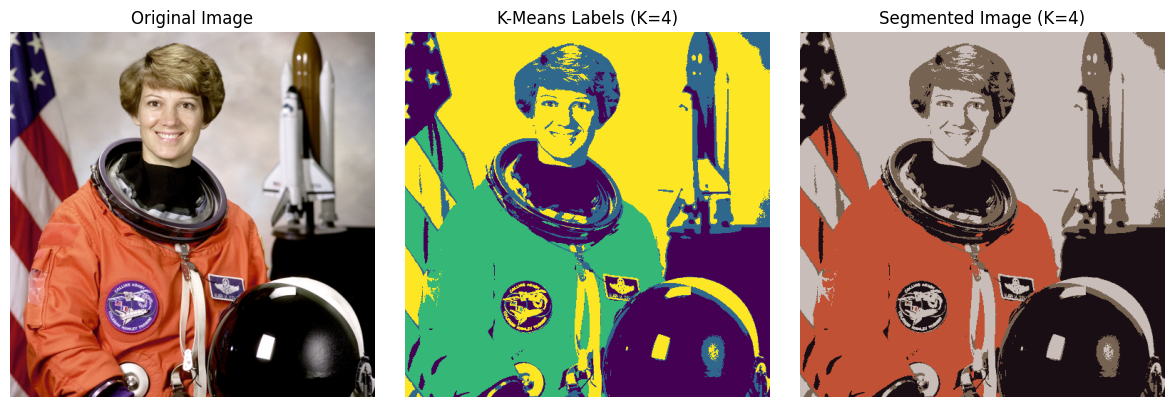

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2lab, lab2rgb
from sklearn.cluster import KMeans
import warnings

# 1. Memuat citra berwarna
image_astro = data.astronaut()
image_float = image_astro.astype(float) / 255.0

# 2. Konversi RGB ke Lab
image_lab = rgb2lab(image_float)

# Ambil ukuran citra
rows, cols, dims = image_lab.shape

# Ubah menjadi data piksel [jumlah_piksel, fitur]
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. K-Means Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Bentuk ulang label ke ukuran citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Membuat citra hasil segmentasi
segmented_lab = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask = (pixel_labels == k).reshape(rows, cols)
    segmented_lab[mask] = centers_lab[k]

# Konversi kembali ke RGB
segmented_rgb = lab2rgb(segmented_lab)

# 6. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(segmented_labels, cmap="viridis")
ax[1].set_title(f"K-Means Labels (K={n_clusters})")
ax[1].axis("off")

ax[2].imshow(segmented_rgb)
ax[2].set_title(f"Segmented Image (K={n_clusters})")
ax[2].axis("off")

plt.tight_layout()
plt.show()

##**PRAKTIKUM 4**
###Segmentasi Berbasis Tepi Menggunakan Watershed

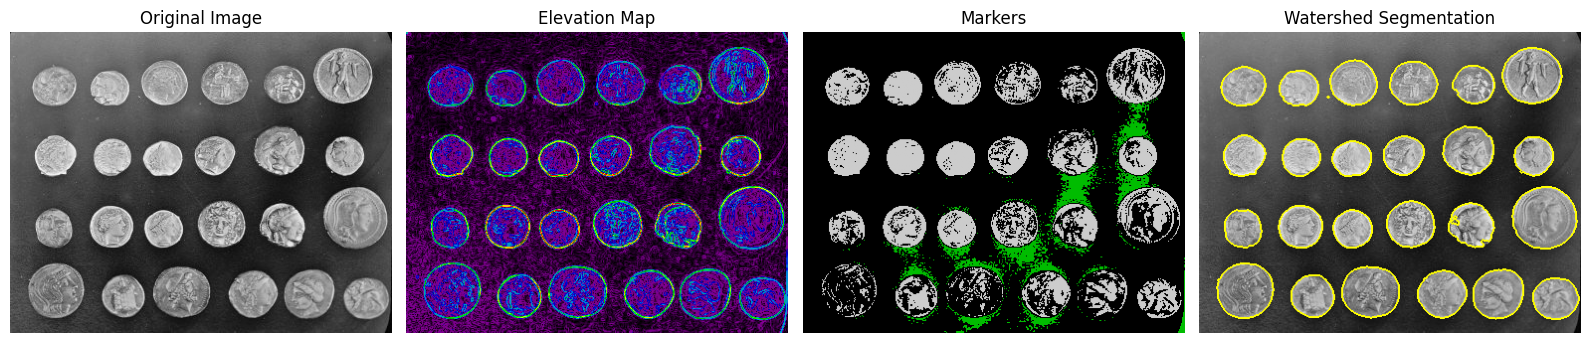

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation

# 1. Memuat citra grayscale
image_coins = data.coins()

# 2. Membuat peta elevasi menggunakan gradien Sobel
elevation_map = filters.sobel(image_coins)

# 3. Membuat marker awal
markers = np.zeros_like(image_coins)

# Marker background
markers[image_coins < 30] = 1

# Marker objek (koin)
markers[image_coins > 150] = 2

# 4. Terapkan Watershed
labels = segmentation.watershed(elevation_map, markers)

# 5. Tandai batas segmentasi pada citra asli
segmented_colored = segmentation.mark_boundaries(image_coins, labels)

# 6. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(elevation_map, cmap='nipy_spectral')
ax[1].set_title("Elevation Map")
ax[1].axis("off")

ax[2].imshow(markers, cmap='nipy_spectral')
ax[2].set_title("Markers")
ax[2].axis("off")

ax[3].imshow(segmented_colored)
ax[3].set_title("Watershed Segmentation")
ax[3].axis("off")

plt.tight_layout()
plt.show()

##**PRAKTIKUM 5**
### Perbandingan Visual Hasil Segmentasi

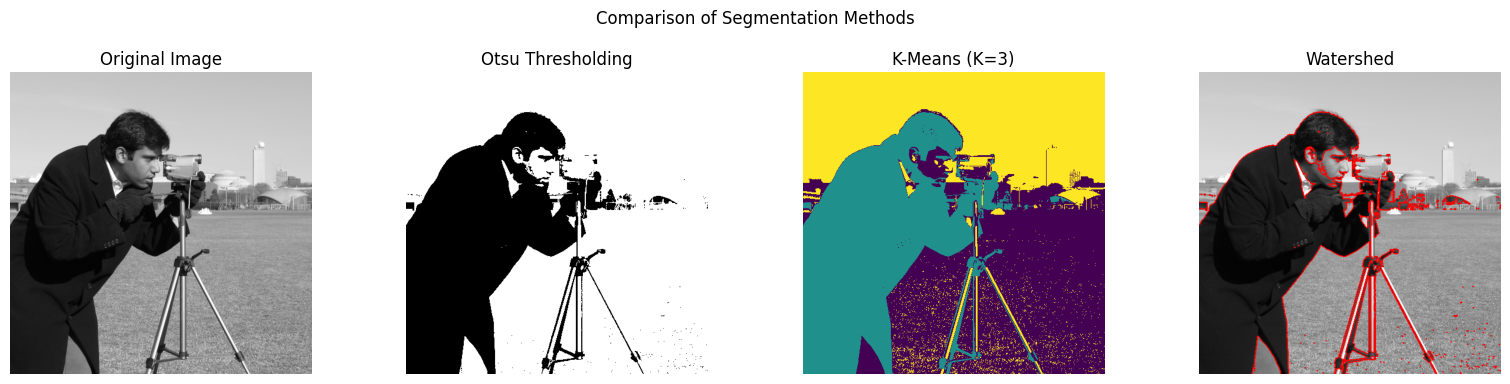

In [5]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Memuat citra grayscale
image = data.camera()
image_float = img_as_float(image)

# =============================
# 2. Beberapa Metode Segmentasi
# =============================

# a. Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b. K-Means Clustering
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans = pixel_labels.reshape(rows, cols)

# c. Watershed
elevation_map = filters.sobel(image)

markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

labels_ws = segmentation.watershed(elevation_map, markers)

# Tandai batas watershed
watershed_result = segmentation.mark_boundaries(
    image_float, labels_ws, color=(1, 0, 0)
)

# =============================
# 3. Visualisasi
# =============================
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu Thresholding")
ax[1].axis("off")

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title(f"K-Means (K={n_clusters})")
ax[2].axis("off")

ax[3].imshow(watershed_result)
ax[3].set_title("Watershed")
ax[3].axis("off")

plt.suptitle("Comparison of Segmentation Methods")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()